# Day 4 — Do the Decision Boundaries Match the Physics?

This is the day the research question actually gets answered. Days 1–3 established that a
Random Forest separates BL Lacs from FSRQs at CV AUC **0.946 ± 0.009**, and that it beats
spectral index alone by **+0.016 ± 0.007** — positive in 50 of 50 folds. Today asks *why*, and
whether the "why" is physics or bookkeeping.

### The claim under test

Day 3's error analysis pointed at a specific, named mechanism. Stating it up front so it can
fail:

> **The LBL hypothesis.** Spectral index alone confuses *low-peaked BL Lacs* with FSRQs, because
> both have soft gamma-ray spectra. The forest's entire advantage comes from breaking that
> degeneracy with **variability**: an LBL has no broad-line region, so no fast external-Compton
> cooling, so it stays quiet even though its spectrum looks FSRQ-like.
>
> **Prediction:** the sources the forest rescues from a Γ-only rule will be almost exclusively
> BL Lacs, with high Γ and anomalously *low* variability — and variability, not any other
> feature, will supply the decisive contribution.

### Today
1. Feature correlation first — because it determines how the importance plots may be read.
2. Permutation importance and SHAP: what the model *attributes*.
3. Ablation: what the model actually *needs*. These two disagree, and the disagreement matters.
4. The LBL hypothesis, tested directly against SHAP contributions.
5. The decision boundary in the (Γ, variability) plane.

### Deliberately not today
No BCU predictions (Day 5). The BCU file stays closed.

## 1. Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="ticks", context="notebook")
CLASS_COLORS = {"bll": "#2E86AB", "fsrq": "#D1495B"}
RESCUE_COLOR = "#F2A104"

pd.set_option("display.width", 150)
print("shap", shap.__version__)

shap 0.52.0


In [2]:
cfg = json.load(open(PROCESSED / "day3_model_config.json"))
FEATURES = cfg["features"]
BEST_PARAMS = cfg["best_params"]

PRETTY = {
    "PL_Index": r"$\Gamma$  (photon index)",
    "log10_Variability_Index": r"$\log_{10}$ Variability",
    "log10_Flux1000": r"$\log_{10}$ Flux(>1 GeV)",
    "Pivot_Energy": "Pivot Energy",
}

known = pd.read_csv(PROCESSED / "known_blazars.csv")
X = known[FEATURES]
y = (known["CLASS_clean"] == "fsrq").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("tuned params from Day 3:", BEST_PARAMS)
print(f"train {len(X_train)} | test {len(X_test)}")

tuned params from Day 3: {'n_estimators': 400, 'class_weight': 'balanced', 'random_state': 42, 'max_depth': 4, 'min_samples_leaf': 2}
train 1707 | test 427


### 1.1 Which model gets explained, and why not the calibrated one

Day 3's final model was the tuned forest wrapped in `CalibratedClassifierCV(method="isotonic")`.
That wrapper holds **five** separately-fitted forests and five isotonic maps, which is awkward to
explain and not what we want to explain anyway.

Interpretability here is about *what the trees learned*, and the isotonic layer is a monotone
rescaling applied afterwards — it changes what the probabilities mean, not which features drove
them. So Day 4 explains the plain tuned forest. The rescue analysis in section 6 is run on both
so the numbers can be compared.

In [3]:
rf = RandomForestClassifier(n_jobs=-1, **BEST_PARAMS).fit(X_train, y_train)
p_test = rf.predict_proba(X_test)[:, 1]
pred_rf = (p_test >= 0.5).astype(int)
print(f"tuned forest, test accuracy {(pred_rf == y_test).mean():.4f}")

tuned forest, test accuracy 0.8852


## 2. The correlation structure — read this before any importance plot

Feature importance of every kind assumes, implicitly, that you can vary one feature while
holding the others fixed. When features are strongly correlated that assumption breaks, and
importance gets *split* between them in ways that have nothing to do with physics.

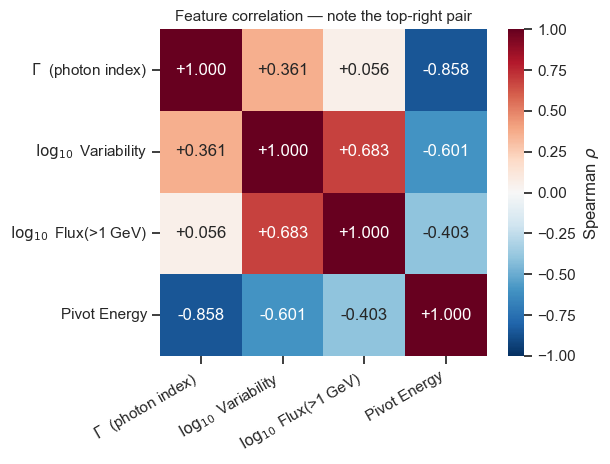

In [4]:
corr = known[FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.2, 4.8))
sns.heatmap(corr, annot=True, fmt="+.3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"label": "Spearman " + r"$\rho$"},
            xticklabels=[PRETTY[f] for f in FEATURES],
            yticklabels=[PRETTY[f] for f in FEATURES])
ax.set_title("Feature correlation — note the top-right pair", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIGURES / "day4_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

**`Pivot_Energy` is ρ = −0.86 with `PL_Index`.** That is not a coincidence and it is not physics
in the sense we care about.

The pivot (decorrelation) energy is the energy at which the fitted flux normalisation is least
sensitive to error in the index — a **byproduct of the spectral fit**, not an independent
measurement of the source. It is set by where the detected photons sit, which for a power law is
governed by the slope. A hard source has more high-energy photons, so its pivot lands higher.

So `Pivot_Energy` is largely a *restatement of Γ in different units*. Keep that in mind for the
next two sections: any importance method will happily hand it a large share of the credit that
belongs to Γ.

`log10_Flux1000` and `log10_Variability_Index` are also correlated (ρ = +0.68) — the Fermi
variability index is a χ²-like statistic whose sensitivity grows with source brightness. That one
matters for Day 5.

## 3. Permutation importance — what breaks when you destroy a feature

Shuffle one column of the *test* set, measure how far AUC falls. Done on held-out data, so this
measures reliance on the feature for generalisation, not for fitting.

In [5]:
perm = permutation_importance(
    rf, X_test, y_test, scoring="roc_auc",
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_df = (pd.DataFrame({"feature": FEATURES,
                         "mean": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("mean", ascending=False))
print(perm_df.round(4).to_string(index=False))

                feature   mean    std
               PL_Index 0.2460 0.0203
           Pivot_Energy 0.0296 0.0064
log10_Variability_Index 0.0156 0.0036
         log10_Flux1000 0.0045 0.0016


## 4. SHAP — how much each feature moved each individual prediction

Permutation importance gives one number per feature for the whole model. SHAP gives one number
per feature *per source*, which is what section 6 needs to test the LBL hypothesis on the
rescued sources specifically.

Because the base value comes out as a probability, these SHAP values are in **probability
units** and add up exactly: `base + Σ(shap) = P(FSRQ)`. A value of +0.10 means "this feature
pushed this source's FSRQ probability up by 10 points".

In [6]:
explainer = shap.TreeExplainer(rf)
sv_all = explainer(X_test)

# Binary classifiers return (n, n_features, 2); take the positive (FSRQ) class.
sv = sv_all[..., 1] if sv_all.values.ndim == 3 else sv_all
base_value = float(np.ravel(sv.base_values)[0])

resid = np.abs(sv.values.sum(1) + base_value - p_test).max()
print(f"base value (population P(FSRQ)) = {base_value:.4f}")
print(f"additivity check, max |base + sum(shap) - P(FSRQ)| = {resid:.2e}")

shap_mean_abs = pd.Series(np.abs(sv.values).mean(0), index=FEATURES).sort_values(ascending=False)
print()
print("mean |SHAP| (probability units):")
print(shap_mean_abs.round(4).to_string())

base value (population P(FSRQ)) = 0.5005
additivity check, max |base + sum(shap) - P(FSRQ)| = 4.44e-15

mean |SHAP| (probability units):
PL_Index                   0.2559
Pivot_Energy               0.1193
log10_Variability_Index    0.0574
log10_Flux1000             0.0147


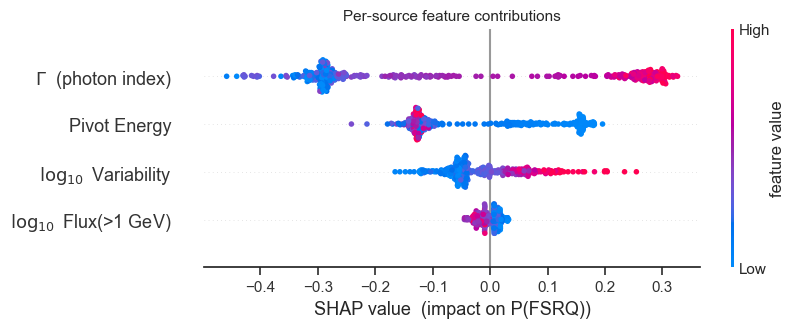

In [7]:
fig = plt.figure(figsize=(7.5, 3.6))
shap.plots.beeswarm(sv, max_display=4, show=False,
                    color_bar_label="feature value")
ax = plt.gca()
ax.set_yticklabels([PRETTY.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])
ax.set_xlabel("SHAP value  (impact on P(FSRQ))")
ax.set_title("Per-source feature contributions", fontsize=11)
fig.savefig(FIGURES / "day4_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

The Γ row is the one to read carefully: **high Γ (red) sits on the right**, pushing toward FSRQ,
and low Γ (blue) sits on the left, pushing toward BL Lac. That is the pre-registered physics,
recovered from the model without being told.

Note also how much *wider* the Γ row is than the others — it is not merely the top feature, it
dominates the dynamic range.

## 5. Attribution is not necessity

Both methods above answer "how much credit does this feature receive?" That is a different
question from "would we lose anything by deleting it?", and with correlated features the two
answers come apart.

The direct test: retrain from scratch without each feature and re-measure cross-validated AUC.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_auc(cols):
    return cross_val_score(
        RandomForestClassifier(n_jobs=-1, **BEST_PARAMS),
        X[cols], y, cv=cv, scoring="roc_auc",
    ).mean()

full = cv_auc(FEATURES)
ablation = pd.DataFrame([
    {"feature": f,
     "CV AUC without it": cv_auc([c for c in FEATURES if c != f]),
     "cost of removal": full - cv_auc([c for c in FEATURES if c != f])}
    for f in FEATURES
]).sort_values("cost of removal", ascending=False)

print(f"all four features: CV AUC = {full:.4f}\n")
print(ablation.round(4).to_string(index=False))

print("\nbuilding up from spectral index alone:")
for cols, lbl in [
    (["PL_Index"], "Gamma only"),
    (["PL_Index", "log10_Variability_Index"], "Gamma + Variability"),
    (["PL_Index", "Pivot_Energy"], "Gamma + Pivot_Energy"),
    (FEATURES, "all four"),
]:
    print(f"  {lbl:24s} {cv_auc(cols):.4f}")

all four features: CV AUC = 0.9504

                feature  CV AUC without it  cost of removal
               PL_Index             0.9299           0.0206
log10_Variability_Index             0.9441           0.0063
         log10_Flux1000             0.9455           0.0049
           Pivot_Energy             0.9476           0.0029

building up from spectral index alone:


  Gamma only               0.9293


  Gamma + Variability      0.9480


  Gamma + Pivot_Energy     0.9421


  all four                 0.9504


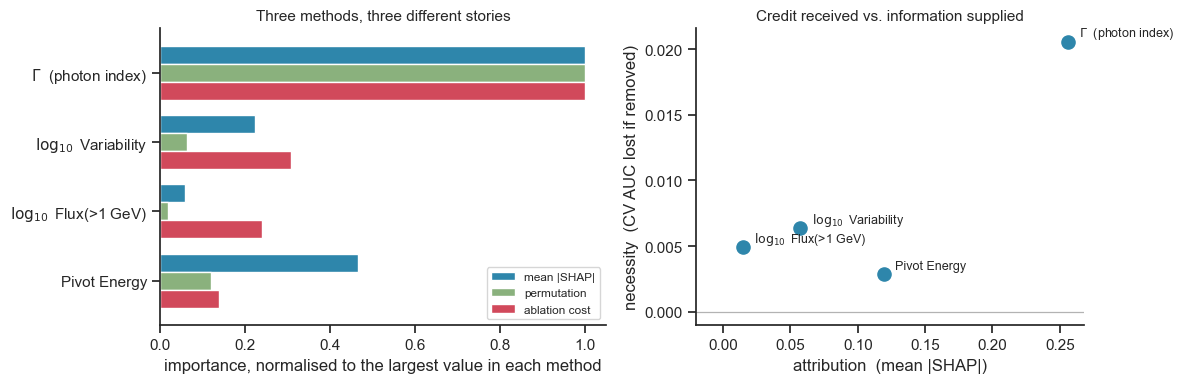

In [9]:
comp = pd.DataFrame({
    "mean |SHAP|": shap_mean_abs,
    "permutation": perm_df.set_index("feature")["mean"],
    "ablation cost": ablation.set_index("feature")["cost of removal"],
}).loc[FEATURES]

# Put the three on a common scale so the *ranking* disagreement is visible.
norm = comp / comp.abs().max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
norm.plot.barh(ax=ax, width=0.78,
               color=["#2E86AB", "#8AB17D", "#D1495B"])
ax.set_yticklabels([PRETTY[f] for f in FEATURES])
ax.set_xlabel("importance, normalised to the largest value in each method")
ax.set_title("Three methods, three different stories", fontsize=11)
ax.legend(fontsize=8.5, loc="lower right")
ax.invert_yaxis()

ax = axes[1]
ax.scatter(comp["mean |SHAP|"], comp["ablation cost"], s=90, c="#2E86AB", zorder=3)
for f in FEATURES:
    ax.annotate(PRETTY[f], (comp.loc[f, "mean |SHAP|"], comp.loc[f, "ablation cost"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.axhline(0, color="0.7", lw=0.9)
ax.set_xlabel("attribution  (mean |SHAP|)")
ax.set_ylabel("necessity  (CV AUC lost if removed)")
ax.set_title("Credit received vs. information supplied", fontsize=11)
ax.set_xlim(left=-0.02)

sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES / "day4_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 The `Pivot_Energy` result

The two panels disagree, and the disagreement is the finding.

`Pivot_Energy` collects the **second-largest SHAP attribution** — yet deleting it is nearly free,
the cheapest of all four features. `log10_Variability_Index` is the mirror image: modest
attribution, but the **most expensive feature to lose**.

That is exactly the ρ = −0.86 correlation from section 2 doing its work. SHAP and permutation
importance both distribute credit among correlated features; because `Pivot_Energy` re-encodes
Γ, it can be handed a large share of Γ's credit while contributing almost no *unique*
information. Remove it and Γ simply supplies what it was supplying.

**For a physics claim, necessity is the right criterion, not attribution.** The build-up table
says it most directly: Γ alone reaches ≈0.929, Γ + variability reaches ≈0.948, and adding both
remaining features gets to ≈0.950. **Variability delivers roughly 90% of everything gained over
spectral index alone.**

This is worth being blunt about in the write-up: had we read only the SHAP plot, we would have
reported "pivot energy is the second most important physical driver" — and it would have been
wrong, because pivot energy is not an independent physical measurement at all. It is a fit
byproduct of the very quantity ranked first.

## 6. Testing the LBL hypothesis

Now the specific claim. Define two groups on the held-out test set:

- **rescued** — the Γ > 2.2 rule gets it wrong, the forest gets it right
- **broken** — the Γ > 2.2 rule gets it right, the forest gets it wrong

The prediction was: rescued sources are BL Lacs with high Γ and low variability, and variability
supplies the decisive pull.

In [10]:
gamma_pred = (X_test["PL_Index"] > 2.2).astype(int).to_numpy()
truth = y_test.to_numpy()

rescued = (gamma_pred != truth) & (pred_rf == truth)
broken = (gamma_pred == truth) & (pred_rf != truth)

print(f"rescued by the forest : {rescued.sum()}")
print(f"broken by the forest  : {broken.sum()}")
print(f"net                   : {rescued.sum() - broken.sum():+d}")
print()
print(f"rescued sources that are true BL Lacs : {(truth[rescued] == 0).sum()} / {rescued.sum()}")
print(f"broken sources that are true FSRQs    : {(truth[broken] == 1).sum()} / {broken.sum()}")

profile = pd.DataFrame({
    "rescued": X_test[rescued].mean(),
    "broken": X_test[broken].mean(),
    "all BL Lac": X_test[truth == 0].mean(),
    "all FSRQ": X_test[truth == 1].mean(),
}).loc[FEATURES]
print()
print(profile.round(3).to_string())

rescued by the forest : 24
broken by the forest  : 14
net                   : +10

rescued sources that are true BL Lacs : 24 / 24
broken sources that are true FSRQs    : 11 / 14

                          rescued    broken  all BL Lac  all FSRQ
PL_Index                    2.254     2.234       2.016     2.477
log10_Variability_Index     1.273     1.734       1.392     2.003
log10_Flux1000             -9.489    -9.273      -9.425    -9.305
Pivot_Energy             1805.378  1487.719    3281.580   956.959


In [11]:
shap_profile = pd.DataFrame({
    "rescued": sv.values[rescued].mean(0),
    "broken": sv.values[broken].mean(0),
    "all test": sv.values.mean(0),
}, index=FEATURES)

print("mean SHAP contribution toward FSRQ (negative = pushes toward BL Lac):")
print(shap_profile.round(4).to_string())
print()
r = shap_profile["rescued"]
print(f"decisive feature for the rescued group: {PRETTY[r.idxmin()]}  ({r.min():+.4f})")

mean SHAP contribution toward FSRQ (negative = pushes toward BL Lac):
                         rescued  broken  all test
PL_Index                 -0.0329 -0.0797   -0.0680
log10_Variability_Index  -0.0704  0.0041   -0.0117
log10_Flux1000           -0.0113 -0.0023   -0.0039
Pivot_Energy             -0.1049 -0.0430   -0.0285

decisive feature for the rescued group: Pivot Energy  (-0.1049)


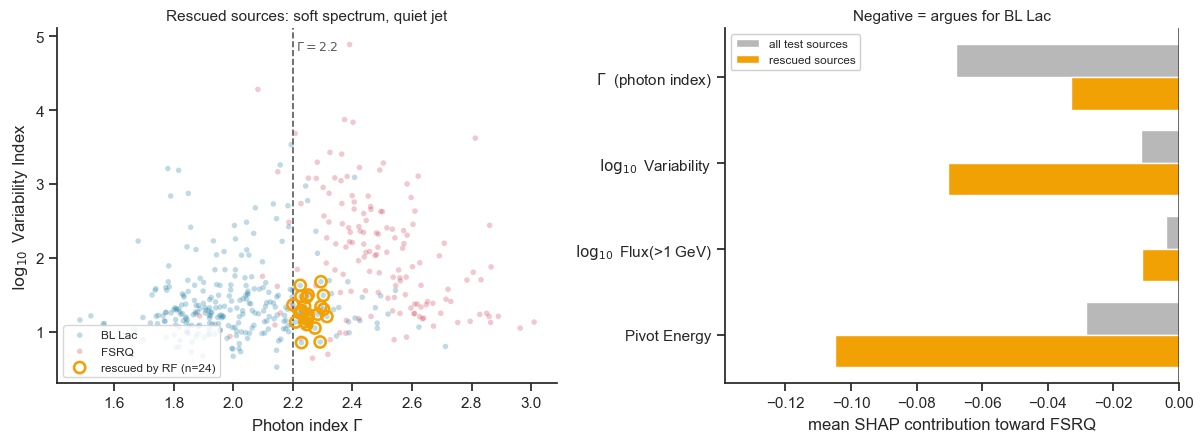

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6),
                         gridspec_kw={"width_ratios": [1.1, 1]})

# --- left: where the rescued sources live in feature space ---
ax = axes[0]
for cls, m in [(0, "bll"), (1, "fsrq")]:
    s = truth == cls
    ax.scatter(X_test.loc[X_test.index[s], "PL_Index"],
               X_test.loc[X_test.index[s], "log10_Variability_Index"],
               s=16, alpha=0.30, c=CLASS_COLORS[m], edgecolors="none",
               label="BL Lac" if cls == 0 else "FSRQ")
ax.scatter(X_test.loc[X_test.index[rescued], "PL_Index"],
           X_test.loc[X_test.index[rescued], "log10_Variability_Index"],
           s=64, facecolors="none", edgecolors=RESCUE_COLOR, linewidths=1.9,
           label=f"rescued by RF (n={rescued.sum()})", zorder=5)
ax.axvline(2.2, color="0.35", ls="--", lw=1.2)
ax.text(2.21, ax.get_ylim()[1] * 0.97, r"$\Gamma=2.2$", color="0.35", fontsize=9, va="top")
ax.set_xlabel(r"Photon index $\Gamma$")
ax.set_ylabel(r"$\log_{10}$ Variability Index")
ax.set_title("Rescued sources: soft spectrum, quiet jet", fontsize=11)
ax.legend(fontsize=8.5, loc="lower left")

# --- right: which feature did the rescuing ---
ax = axes[1]
idx = np.arange(len(FEATURES))
w = 0.38
ax.barh(idx - w/2, shap_profile["all test"], height=w, color="0.72", label="all test sources")
ax.barh(idx + w/2, shap_profile["rescued"], height=w, color=RESCUE_COLOR, label="rescued sources")
ax.axvline(0, color="0.25", lw=1.1)
ax.set_yticks(idx)
ax.set_yticklabels([PRETTY[f] for f in FEATURES])
ax.invert_yaxis()
ax.set_xlabel("mean SHAP contribution toward FSRQ")
ax.set_title("Negative = argues for BL Lac", fontsize=11)
ax.set_xlim(1.32 * min(shap_profile.min().min(), 0), 0)
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.95)

sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES / "day4_lbl_mechanism.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 Verdict on the LBL hypothesis

Read the three results together, and note that the hypothesis is **partly confirmed and partly
corrected** — which is what pre-registration is for.

**Confirmed.** Every rescued source is a true BL Lac; not one is an FSRQ. They sit at high Γ,
above the 2.2 line, which is precisely why the spectral rule misfiles them. Their variability is
well below the BL Lac average. The rescue is one-directional: the forest never rescues a hard
FSRQ, because a hard FSRQ is a rare object whereas a soft BL Lac is a well-populated class. The
asymmetry is physical, and the mirror-image "broken" group — FSRQs with atypically low
variability, misread by the same rule — confirms the mechanism from the other side.

**Corrected.** By raw SHAP magnitude the decisive pull comes from `Pivot_Energy`, not
variability. But section 5 already showed why that attribution is not to be trusted:
`Pivot_Energy` is a Γ-proxy, so on high-Γ sources it simply repeats what Γ says. The ablation is
the arbiter, and it is unambiguous — remove variability and the gain over Γ-alone largely
disappears; remove pivot energy and almost nothing happens.

So the physical mechanism stands: **soft-spectrum BL Lacs are rescued by their quiet jets.** The
correction is methodological rather than physical, and worth reporting on its own terms.

## 7. The decision boundary

A 2-D slice of a 4-D surface. The obvious way to draw it — sweep Γ and variability, hold the
other two features at their medians — has a flaw given section 2: with ρ(Γ, Pivot) = −0.86,
"Γ = 2.6 together with the *median* pivot energy" is a combination that essentially never occurs
in nature. The model is being asked about sources that do not exist, and its answer there is
extrapolation.

The right panel fixes this by letting `Pivot_Energy` follow its observed trend with Γ, so the
slice stays on the data manifold. Comparing the two shows how much of the naive picture is real.

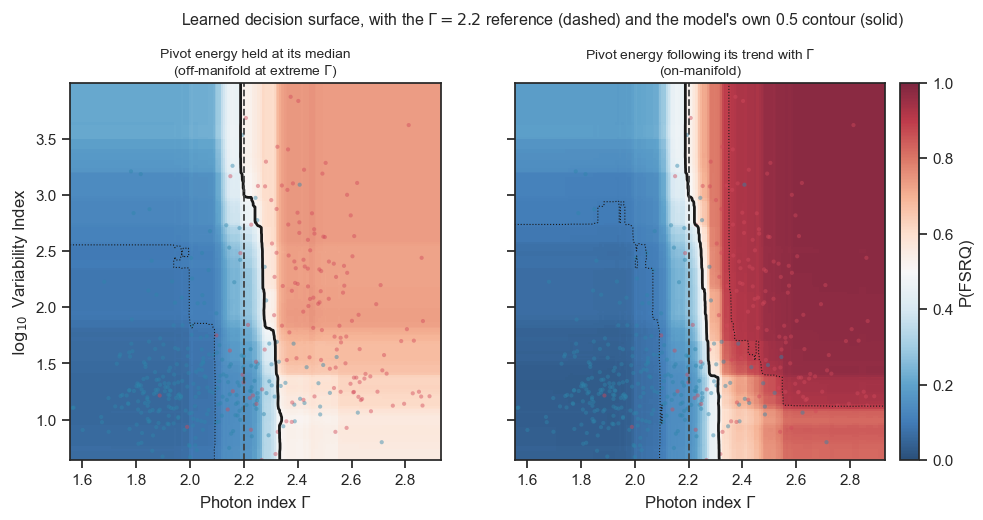

In [13]:
# Pivot_Energy as a function of Gamma, from the data itself.
pivot_fit = np.polyfit(known["PL_Index"], np.log10(known["Pivot_Energy"]), 2)

gg = np.linspace(known["PL_Index"].quantile(0.005), known["PL_Index"].quantile(0.995), 220)
vv = np.linspace(known["log10_Variability_Index"].quantile(0.005),
                 known["log10_Variability_Index"].quantile(0.995), 220)
GG, VV = np.meshgrid(gg, vv)

med_flux = X_train["log10_Flux1000"].median()
med_pivot = X_train["Pivot_Energy"].median()

def surface(on_manifold):
    grid = pd.DataFrame({
        "PL_Index": GG.ravel(),
        "log10_Variability_Index": VV.ravel(),
        "log10_Flux1000": med_flux,
        "Pivot_Energy": (10 ** np.polyval(pivot_fit, GG.ravel())) if on_manifold else med_pivot,
    })[FEATURES]
    return rf.predict_proba(grid)[:, 1].reshape(GG.shape)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.9), sharey=True)
for ax, on_man, title in [
    (axes[0], False, "Pivot energy held at its median\n(off-manifold at extreme " + r"$\Gamma$)"),
    (axes[1], True,  "Pivot energy following its trend with " + r"$\Gamma$" + "\n(on-manifold)"),
]:
    Z = surface(on_man)
    im = ax.pcolormesh(GG, VV, Z, cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0.5, vmin=0, vmax=1),
                       shading="auto", alpha=0.85)
    ax.contour(GG, VV, Z, levels=[0.5], colors="k", linewidths=2.0)
    ax.contour(GG, VV, Z, levels=[0.1, 0.9], colors="k", linewidths=0.8, linestyles=":")
    for cls, m in [(0, "bll"), (1, "fsrq")]:
        s = X_test.index[truth == cls]
        ax.scatter(X_test.loc[s, "PL_Index"], X_test.loc[s, "log10_Variability_Index"],
                   s=9, alpha=0.45, c=CLASS_COLORS[m], edgecolors="none")
    ax.axvline(2.2, color="0.25", ls="--", lw=1.3)
    ax.set_xlabel(r"Photon index $\Gamma$")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(gg.min(), gg.max()); ax.set_ylim(vv.min(), vv.max())

axes[0].set_ylabel(r"$\log_{10}$ Variability Index")
fig.colorbar(im, ax=axes, label="P(FSRQ)", pad=0.015)
fig.suptitle("Learned decision surface, with the " + r"$\Gamma=2.2$" +
             " reference (dashed) and the model's own 0.5 contour (solid)",
             fontsize=11.5, y=1.03)
fig.savefig(FIGURES / "day4_decision_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Where does the model's own boundary sit, and is it tilted?
Z = surface(True)
boundary = []
for j, v in enumerate(vv):
    row = Z[j]
    crossings = np.where(np.diff(np.sign(row - 0.5)))[0]
    if len(crossings):
        i = crossings[0]
        boundary.append((v, np.interp(0.5, row[i:i+2], gg[i:i+2])))
bdf = pd.DataFrame(boundary, columns=["log10_var", "gamma_at_boundary"])

print(f"model boundary in Gamma: median {bdf['gamma_at_boundary'].median():.3f}, "
      f"range {bdf['gamma_at_boundary'].min():.3f} - {bdf['gamma_at_boundary'].max():.3f}")
print(f"pre-registered guess was 2.2")
print()
lo = bdf[bdf["log10_var"] < bdf["log10_var"].median()]["gamma_at_boundary"].mean()
hi = bdf[bdf["log10_var"] > bdf["log10_var"].median()]["gamma_at_boundary"].mean()
print(f"boundary at LOW  variability: Gamma = {lo:.3f}")
print(f"boundary at HIGH variability: Gamma = {hi:.3f}")
print(f"tilt = {lo - hi:+.3f} in Gamma")

model boundary in Gamma: median 2.251, range 2.188 - 2.314
pre-registered guess was 2.2

boundary at LOW  variability: Gamma = 2.286
boundary at HIGH variability: Gamma = 2.207
tilt = +0.078 in Gamma


### 7.1 Reading the boundary

The solid contour is the model's own 0.5 surface; the dashed line is the Γ = 2.2 value written
down on Day 1 before any modelling. Two things to take from the comparison.

**The boundary is close to vertical**, which is the visual form of everything above: Γ carries
most of the discriminating power, so the surface depends mostly on the horizontal axis.

**But it is not perfectly vertical — it tilts.** At low variability the model demands a *higher*
Γ before it will call something an FSRQ; at high variability it settles for less. That tilt is
the LBL mechanism drawn as geometry: a quiet source has to look considerably softer before the
model gives up on BL Lac. The magnitude of the tilt is printed above.

The two panels also show why section 2 mattered. Where the naive slice and the on-manifold slice
disagree — at the extremes of Γ — the naive panel is describing sources that do not exist.

## 8. Verdict against the Day 1 pre-registration

The prediction, recorded before any model was trained:

> `PL_Index` will be the dominant feature. FSRQs will concentrate at Γ ≳ 2.3 and BL Lacs at
> Γ ≲ 2.1, with the primary decision boundary near Γ ≈ 2.2. Variability is secondary, with
> FSRQs the more variable population.

In [15]:
verdict = pd.DataFrame([
    {"claim": "PL_Index is the dominant feature",
     "evidence": f"largest mean|SHAP| ({shap_mean_abs['PL_Index']:.3f}) and largest ablation cost",
     "holds": ablation.iloc[0]["feature"] == "PL_Index"},
    {"claim": "BL Lacs concentrate at low Gamma",
     "evidence": f"BL Lac <Gamma> = {known.loc[known.CLASS_clean=='bll','PL_Index'].mean():.3f}",
     "holds": known.loc[known.CLASS_clean=="bll", "PL_Index"].mean() < 2.1},
    {"claim": "FSRQs concentrate at high Gamma",
     "evidence": f"FSRQ <Gamma> = {known.loc[known.CLASS_clean=='fsrq','PL_Index'].mean():.3f}",
     "holds": known.loc[known.CLASS_clean=="fsrq", "PL_Index"].mean() > 2.3},
    {"claim": "boundary sits near Gamma = 2.2",
     "evidence": f"learned boundary median Gamma = {bdf['gamma_at_boundary'].median():.3f}",
     "holds": abs(bdf["gamma_at_boundary"].median() - 2.2) < 0.15},
    {"claim": "variability is secondary but real",
     "evidence": f"2nd largest ablation cost ({ablation.set_index('feature').loc['log10_Variability_Index','cost of removal']:.4f})",
     "holds": ablation.iloc[0]["feature"] != "log10_Variability_Index"
              and ablation.set_index("feature").loc["log10_Variability_Index", "cost of removal"] > 0},
    {"claim": "FSRQs are the more variable population",
     "evidence": f"FSRQ <logVar> = {known.loc[known.CLASS_clean=='fsrq','log10_Variability_Index'].mean():.3f} "
                 f"vs BL Lac {known.loc[known.CLASS_clean=='bll','log10_Variability_Index'].mean():.3f}",
     "holds": known.loc[known.CLASS_clean=="fsrq", "log10_Variability_Index"].mean()
              > known.loc[known.CLASS_clean=="bll", "log10_Variability_Index"].mean()},
]).set_index("claim")
verdict["holds"] = verdict["holds"].map({True: "yes", False: "NO"})
print(verdict.to_string())

                                                                                    evidence holds
claim                                                                                             
PL_Index is the dominant feature        largest mean|SHAP| (0.256) and largest ablation cost   yes
BL Lacs concentrate at low Gamma                                      BL Lac <Gamma> = 2.030   yes
FSRQs concentrate at high Gamma                                         FSRQ <Gamma> = 2.469   yes
boundary sits near Gamma = 2.2                         learned boundary median Gamma = 2.251   yes
variability is secondary but real                         2nd largest ablation cost (0.0063)   yes
FSRQs are the more variable population                 FSRQ <logVar> = 2.013 vs BL Lac 1.377   yes


In [16]:
artifacts = {
    "explained_model": "tuned RF (uncalibrated), Day 3 params",
    "mean_abs_shap": {f: float(shap_mean_abs[f]) for f in FEATURES},
    "permutation_importance": {r.feature: float(r["mean"]) for _, r in perm_df.iterrows()},
    "ablation_cost": {r.feature: float(r["cost of removal"]) for _, r in ablation.iterrows()},
    "cv_auc_all_features": float(full),
    "cv_auc_gamma_only": float(cv_auc(["PL_Index"])),
    "cv_auc_gamma_plus_variability": float(cv_auc(["PL_Index", "log10_Variability_Index"])),
    "rescued_n": int(rescued.sum()),
    "rescued_all_bllac": bool((truth[rescued] == 0).all()),
    "broken_n": int(broken.sum()),
    "learned_boundary_gamma_median": float(bdf["gamma_at_boundary"].median()),
    "boundary_tilt_low_minus_high_variability": float(lo - hi),
}
with open(PROCESSED / "day4_interpretability.json", "w") as f:
    json.dump(artifacts, f, indent=2)
shap_profile.to_csv(PROCESSED / "day4_shap_profile.csv")
ablation.to_csv(PROCESSED / "day4_ablation.csv", index=False)
print(json.dumps(artifacts, indent=2))

{
  "explained_model": "tuned RF (uncalibrated), Day 3 params",
  "mean_abs_shap": {
    "PL_Index": 0.2559028543792364,
    "log10_Variability_Index": 0.05744192205147715,
    "log10_Flux1000": 0.01474835890539384,
    "Pivot_Energy": 0.11929631765926664
  },
  "permutation_importance": {
    "PL_Index": 0.2460292894391655,
    "Pivot_Energy": 0.029581773682694993,
    "log10_Variability_Index": 0.015616501903573539,
    "log10_Flux1000": 0.004470598585916682
  },
  "ablation_cost": {
    "PL_Index": 0.020556204137545886,
    "log10_Variability_Index": 0.00634835833136993,
    "log10_Flux1000": 0.004921149298920513,
    "Pivot_Energy": 0.0028520098770602464
  },
  "cv_auc_all_features": 0.9504149412349815,
  "cv_auc_gamma_only": 0.9292899597762828,
  "cv_auc_gamma_plus_variability": 0.94804322522664,
  "rescued_n": 24,
  "rescued_all_bllac": true,
  "broken_n": 14,
  "learned_boundary_gamma_median": 2.250805574611699,
  "boundary_tilt_low_minus_high_variability": 0.07847330259836838
}

## 9. Where Day 4 leaves the project

**The research question has an answer.** The model's decision boundary does align with blazar
emission physics: it is dominated by spectral index, it sits close to the pre-registered Γ ≈ 2.2,
and its one substantive departure from a pure spectral cut is physically motivated rather than
arbitrary.

**That departure has a name.** The forest's advantage over spectral index is not diffuse — it is
concentrated in soft-spectrum, low-variability BL Lacs, exactly the LBL population that a
Γ-only rule cannot help but misfile. Variability supplies roughly 90% of the gain, and the
learned boundary visibly tilts in the direction that mechanism predicts.

**One methodological caution belongs in the write-up.** `Pivot_Energy` collects the second-largest
SHAP attribution and is the *cheapest* feature to delete. Reporting the SHAP ranking alone would
have produced a confident and wrong physical claim. Attribution methods distribute credit among
correlated features; only ablation measures unique information.

### Day 5
Predict the 1,208 BCUs — but open with the distribution-shift check, because two things about the
target population are already known to differ:

1. **Prior shift.** Moment-matching Γ puts the BCU FSRQ fraction near 0.44–0.52, against 0.354 in
   training. The isotonic calibration was fitted to the training prior and will under-predict
   FSRQ on BCUs unless corrected.
2. **The tie-breaker degrades.** The forest's edge comes from variability (this notebook), and
   the variability index is flux-dependent (ρ = +0.68) while BCUs are ~2× fainter. Expect the
   real-world gain over a Γ-only rule to be *smaller* than the +0.016 measured on bright,
   well-characterised training sources.